# Loss Functions, Part 1
## From prediction error to embedding geometry

This recitation answers one practical question:

> **What training behavior does each loss reward?**

The examples use battery estimation, intent routing, transaction risk, and audio-event embeddings. The notebook is designed to run top-to-bottom with PyTorch, NumPy, and Matplotlib.

## Learning goals

By the end, you should be able to:

1. Explain why loss is a training signal, not just a score.
2. Organize losses as error-based, probabilistic, or margin/metric-based objectives.
3. Compare signed error, MAE, MSE, and Huber Loss for regression.
4. Use multiclass cross-entropy and binary cross-entropy correctly with **logits**.
5. Distinguish fixed-class classification from transferable embedding learning.
6. Explain how Center Loss, Angular Softmax, AM-Softmax, Contrastive Loss, and Triplet Loss reshape embeddings.
7. Select a loss from the structure of the task and debug common implementation mistakes.

## A map of the Part 1 loss landscape

We will organize the session by **what the loss asks the model to optimize**:

| Family | Core question | Examples in this notebook |
|---|---|---|
| Error-based | How large is the prediction residual? | Signed error, MAE, MSE, Huber |
| Probabilistic | How much probability reaches the correct outcome? | Cross-Entropy, BCE with logits |
| Representation-based | Is the embedding space compact and separated? | Center Loss, Angular Softmax, AM-Softmax |
| Comparison-based | Are similar samples closer than dissimilar samples? | Contrastive Loss, Triplet Loss |

This taxonomy is more useful than memorizing a list: it tells us what information the loss consumes and what behavior its gradient rewards.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(7)
np.random.seed(7)
plt.style.use('seaborn-v0_8-whitegrid')

print('PyTorch version:', torch.__version__)

PyTorch version: 2.9.1


## 1. The mental model: output → loss → gradient → update

A loss function maps a model output and a target to one scalar:

$$L = \ell(f_\theta(x), y)$$

Backpropagation differentiates that scalar with respect to the model parameters:

$$\theta \leftarrow \theta - \eta \nabla_\theta L$$

The loss therefore defines the **geometry of the error**. Two losses can see the same prediction and send very different gradients.

In [ ]:
# A compact, correct training-step pattern.
# The loss is computed after the forward pass and before backward().

model = nn.Linear(3, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
x = torch.tensor([[1.0, 0.2, -0.1], [0.3, 0.7, 0.5]])
target = torch.tensor([[0.8], [0.1]])

optimizer.zero_grad()
prediction = model(x)
loss = F.mse_loss(prediction, target)
loss.backward()
optimizer.step()

print(f'One training-step loss: {loss.item():.4f}')

One training-step loss: 0.2238


## 2. Regression: Mean Squared Error

For a batch of $N$ scalar predictions,

$$\mathrm{MSE}=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2$$

For one residual $r=\hat{y}-y$, the gradient is $2r$. Large mistakes receive proportionally larger updates.

In [ ]:
# Example: predicting remaining battery life in hours.
y_true = torch.tensor([7.5, 5.0, 3.0, 1.5])
mostly_close = torch.tensor([7.0, 5.4, 2.6, 1.8])
one_large_miss = torch.tensor([7.0, 5.4, 2.6, 6.0])

def summarize_regression(prediction, target):
    residual = prediction - target
    return {
        'residuals': residual.tolist(),
        'MAE': residual.abs().mean().item(),
        'MSE': residual.square().mean().item(),
    }

print('Mostly close:', summarize_regression(mostly_close, y_true))
print('One large miss:', summarize_regression(one_large_miss, y_true))

Mostly close: {'residuals': [-0.5, 0.40000009536743164, -0.40000009536743164, 0.2999999523162842], 'MAE': 0.40000003576278687, 'MSE': 0.1650000363588333}
One large miss: {'residuals': [-0.5, 0.40000009536743164, -0.40000009536743164, 4.5], 'MAE': 1.4500000476837158, 'MSE': 5.204999923706055}


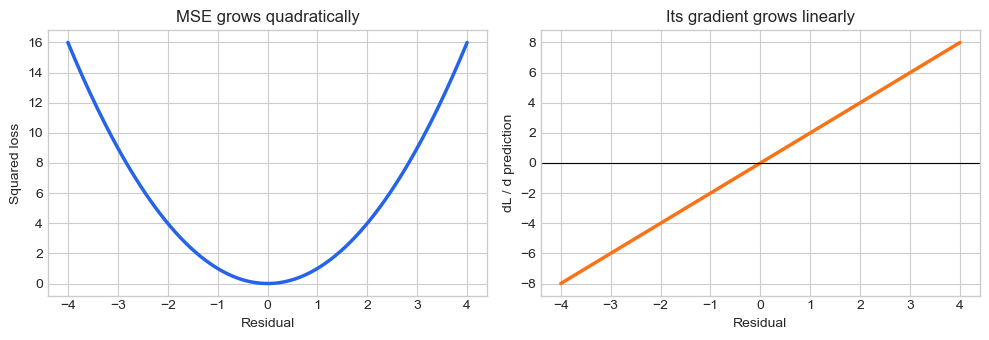

In [ ]:
residual = torch.linspace(-4, 4, 161)
mse_value = residual.square()
mse_gradient = 2 * residual

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(residual, mse_value, color='#2563eb', linewidth=2.5)
axes[0].set(title='MSE grows quadratically', xlabel='Residual', ylabel='Squared loss')
axes[1].plot(residual, mse_gradient, color='#f97316', linewidth=2.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set(title='Its gradient grows linearly', xlabel='Residual', ylabel='dL / d prediction')
plt.tight_layout()
plt.show()

### From distance to regression loss

A raw signed residual $r=\hat{y}-y$ tells us whether we are above or below the target, but positive and negative residuals can cancel when averaged. Practical losses transform the residual before reduction:

- **Mean Bias Error:** mean signed residual; useful as a diagnostic for systematic over/under-prediction, not usually as the only training loss.
- **Mean Absolute Error (L1):** $|r|$; linear penalty and constant gradient magnitude away from zero.
- **Mean Squared Error (L2):** $r^2$; quadratic penalty and stronger gradients for large mistakes.
- **Huber Loss:** quadratic near zero and linear for large residuals; a compromise between smoothness and outlier robustness.

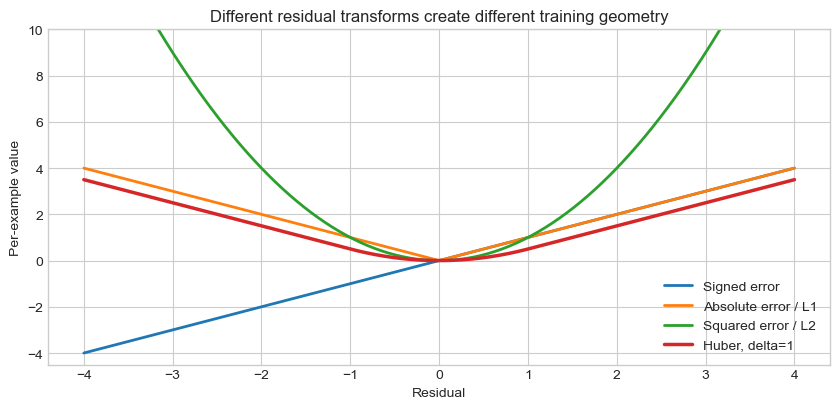

In [ ]:
residual = torch.linspace(-4, 4, 401)
delta = 1.0

signed_error = residual
absolute_error = residual.abs()
squared_error = residual.square()
huber_error = F.huber_loss(residual, torch.zeros_like(residual), delta=delta, reduction='none')

plt.figure(figsize=(8.5, 4.2))
plt.plot(residual, signed_error, label='Signed error', linewidth=2)
plt.plot(residual, absolute_error, label='Absolute error / L1', linewidth=2)
plt.plot(residual, squared_error, label='Squared error / L2', linewidth=2)
plt.plot(residual, huber_error, label='Huber, delta=1', linewidth=2.5)
plt.ylim(-4.5, 10)
plt.xlabel('Residual')
plt.ylabel('Per-example value')
plt.title('Different residual transforms create different training geometry')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def regression_loss_comparison(prediction, target):
    residual = prediction - target
    return {
        'Mean bias': residual.mean().item(),
        'MAE': F.l1_loss(prediction, target).item(),
        'MSE': F.mse_loss(prediction, target).item(),
        'Huber': F.huber_loss(prediction, target, delta=1.0).item(),
    }

print('Mostly close')
print(regression_loss_comparison(mostly_close, y_true))
print()
print('One large miss')
print(regression_loss_comparison(one_large_miss, y_true))

Mostly close
{'Mean bias': -0.050000011920928955, 'MAE': 0.40000003576278687, 'MSE': 0.1650000363588333, 'Huber': 0.08250001817941666}

One large miss
{'Mean bias': 1.0, 'MAE': 1.4500000476837158, 'MSE': 5.204999923706055, 'Huber': 1.0712499618530273}


**Checkpoint.** MSE is a strong default when large residuals truly deserve much larger penalties. If extreme values are noisy or unreliable, compare against MAE or Huber Loss before deciding.

## 3. Multiclass classification: Cross-Entropy

A classifier emits one **logit** $z_c$ per class. Softmax converts logits to probabilities, and cross-entropy penalizes the negative log-probability of the correct class:

$$p_c=\frac{e^{z_c}}{\sum_j e^{z_j}}, \qquad L=-\log p_{y}$$

In PyTorch, `F.cross_entropy(logits, class_indices)` combines `log_softmax` and negative log-likelihood in a stable implementation.

In [ ]:
intents = ['book_flight', 'cancel_booking', 'weather', 'play_music']
logits = torch.tensor([
    [2.2, 0.3, -0.4, 0.1],
    [0.4, 0.8, 1.6, -0.2],
    [-0.3, 0.1, 0.2, 2.0],
])
target_class = torch.tensor([0, 2, 3])

probabilities = logits.softmax(dim=1)
per_example_ce = F.cross_entropy(logits, target_class, reduction='none')

for i in range(len(logits)):
    predicted = intents[probabilities[i].argmax().item()]
    confidence = probabilities[i].max().item()
    print(f'Example {i}: predicted={predicted:15s} confidence={confidence:.3f} loss={per_example_ce[i]:.3f}')

Example 0: predicted=book_flight     confidence=0.743 loss=0.297
Example 1: predicted=weather         confidence=0.522 loss=0.650
Example 2: predicted=play_music      confidence=0.707 loss=0.347


In [ ]:
log_probs = F.log_softmax(logits, dim=1)
manual_ce = -log_probs[torch.arange(len(target_class)), target_class].mean()
builtin_ce = F.cross_entropy(logits, target_class)

print(f'Manual CE:  {manual_ce.item():.6f}')
print(f'PyTorch CE: {builtin_ce.item():.6f}')
print('Match:', torch.allclose(manual_ce, builtin_ce))

Manual CE:  0.431575
PyTorch CE: 0.431575
Match: True


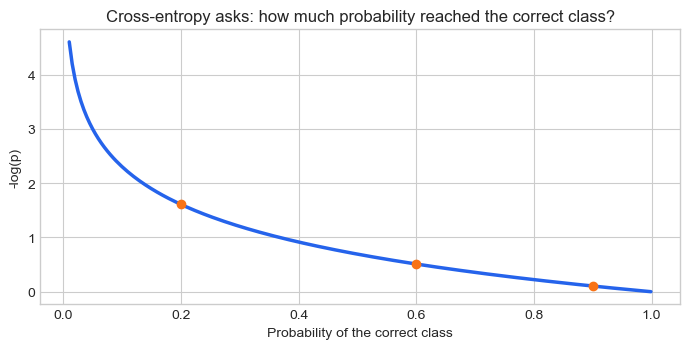

In [ ]:
p_correct = torch.linspace(0.01, 0.999, 200)
penalty = -torch.log(p_correct)

plt.figure(figsize=(7, 3.6))
plt.plot(p_correct, penalty, color='#2563eb', linewidth=2.5)
plt.scatter([0.2, 0.6, 0.9], -torch.log(torch.tensor([0.2, 0.6, 0.9])), color='#f97316', zorder=3)
plt.title('Cross-entropy asks: how much probability reached the correct class?')
plt.xlabel('Probability of the correct class')
plt.ylabel('-log(p)')
plt.tight_layout()
plt.show()

### Common bug: applying softmax twice

`CrossEntropyLoss` expects raw logits. If probabilities are passed instead, PyTorch treats those probabilities as if they were logits and applies another softmax internally.

In [ ]:
correct = F.cross_entropy(logits, target_class)
incorrect_double_softmax = F.cross_entropy(logits.softmax(dim=1), target_class)

print(f'Correct, logits in:          {correct.item():.4f}')
print(f'Incorrect, probabilities in: {incorrect_double_softmax.item():.4f}')

Correct, logits in:          0.4316
Incorrect, probabilities in: 1.0116


## 4. Binary classification: BCE with logits

A binary classifier needs one logit $z$ per example. Its probability is $p=\sigma(z)$, and binary cross-entropy is

$$L=-[y\log p + (1-y)\log(1-p)]$$

Prefer `BCEWithLogitsLoss`: it combines sigmoid and BCE using a numerically stable formulation.

In [ ]:
# Example: transaction risk. One logit per transaction.
risk_logits = torch.tensor([2.4, -1.2, 0.3, -3.0])
is_fraud = torch.tensor([1.0, 0.0, 1.0, 0.0])

bce = F.binary_cross_entropy_with_logits(risk_logits, is_fraud, reduction='none')
risk_probability = risk_logits.sigmoid()

for i, (p, y, l) in enumerate(zip(risk_probability, is_fraud, bce)):
    print(f'Transaction {i}: p(fraud)={p:.3f}, target={int(y.item())}, loss={l:.3f}')
print('Mean BCE:', bce.mean().item())

Transaction 0: p(fraud)=0.917, target=1, loss=0.087
Transaction 1: p(fraud)=0.231, target=0, loss=0.263
Transaction 2: p(fraud)=0.574, target=1, loss=0.554
Transaction 3: p(fraud)=0.047, target=0, loss=0.049
Mean BCE: 0.2382652759552002


In [ ]:
# Numerical stability matters when logits are extreme.
extreme_logits = torch.tensor([80.0, -80.0])
extreme_targets = torch.tensor([1.0, 0.0])

stable = F.binary_cross_entropy_with_logits(extreme_logits, extreme_targets)
probabilities = extreme_logits.sigmoid()
naive = -(extreme_targets * torch.log(probabilities) + (1 - extreme_targets) * torch.log(1 - probabilities)).mean()

print('Stable BCEWithLogitsLoss:', stable.item())
print('Naive probability formula:', naive.item())

Stable BCEWithLogitsLoss: 9.024256642924203e-36
Naive probability formula: nan


**Shape check.** For binary classification, logits and targets normally have the same floating-point shape, such as `[batch]` or `[batch, 1]`. For multiclass cross-entropy, logits are `[batch, classes]` and targets are integer class indices `[batch]`.

## Classification boundaries versus transferable representations

A conventional classifier is evaluated on a fixed set of training classes. It only needs a boundary that sends each example to the correct output.

In retrieval, verification, and zero-shot transfer, the representation itself must remain useful for classes that were not present as output nodes during training. The geometry matters:

- same-class examples should form compact neighborhoods;
- different classes should be separated;
- distances or angles should remain meaningful for new examples.

Cross-entropy can still learn useful features, especially with many diverse training classes, but representation losses make compactness, angular separation, or relative distance explicit.

### What “zero-shot loss” means in this Part 1 context

The phrase is being used broadly for objectives that support generalization beyond the exact training identities. The loss does not magically create unseen labels. Instead, it trains an embedding where a new class can be handled by comparison, nearest neighbors, prototypes, or a new lightweight classifier.

Common applications include speaker verification, face verification, image retrieval, and audio-event matching.

## 5. A change of objective: from predictions to embeddings

Prediction losses ask: **Did the model choose the correct output?**

Embedding losses ask: **Is the representation space useful?**

Useful embeddings often need two properties:

- **Compactness:** examples from the same class stay close.
- **Separation:** examples from different classes stay far apart.

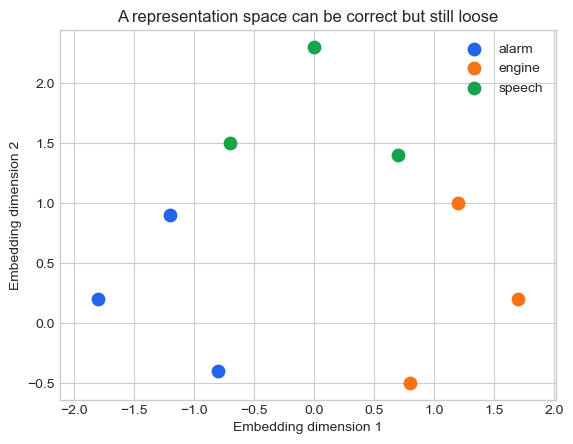

In [ ]:
# A small synthetic embedding batch with three audio-event classes.
labels = torch.tensor([0, 0, 0, 1, 1, 1, 2, 2, 2])
embeddings = torch.tensor([
    [-1.8,  0.2], [-1.2,  0.9], [-0.8, -0.4],
    [ 1.7,  0.2], [ 1.2,  1.0], [ 0.8, -0.5],
    [ 0.0,  2.3], [-0.7,  1.5], [ 0.7,  1.4],
], dtype=torch.float32)

colors = ['#2563eb', '#f97316', '#16a34a']
names = ['alarm', 'engine', 'speech']
for c in range(3):
    pts = embeddings[labels == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=80, label=names[c], color=colors[c])
plt.title('A representation space can be correct but still loose')
plt.xlabel('Embedding dimension 1')
plt.ylabel('Embedding dimension 2')
plt.legend()
plt.axis('equal')
plt.show()

## 6. Center Loss: make each class compact

Center Loss learns one center $c_k$ per class and penalizes squared distance to the correct center:

$$L_{center}=\frac{1}{2N}\sum_i\lVert x_i-c_{y_i}\rVert_2^2$$

It is usually an **auxiliary loss**:

$$L = L_{CE} + \lambda L_{center}$$

Cross-entropy preserves discrimination; Center Loss adds within-class compactness.

In [ ]:
class CenterLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, embedding_dim))

    def forward(self, x, labels):
        selected_centers = self.centers[labels]
        return 0.5 * (x - selected_centers).square().sum(dim=1).mean()

center_objective = CenterLoss(num_classes=3, embedding_dim=2)
initial_center_loss = center_objective(embeddings, labels)
print(f'Initial Center Loss: {initial_center_loss.item():.4f}')
print('Learnable center shape:', tuple(center_objective.centers.shape))

Initial Center Loss: 1.6711
Learnable center shape: (3, 2)


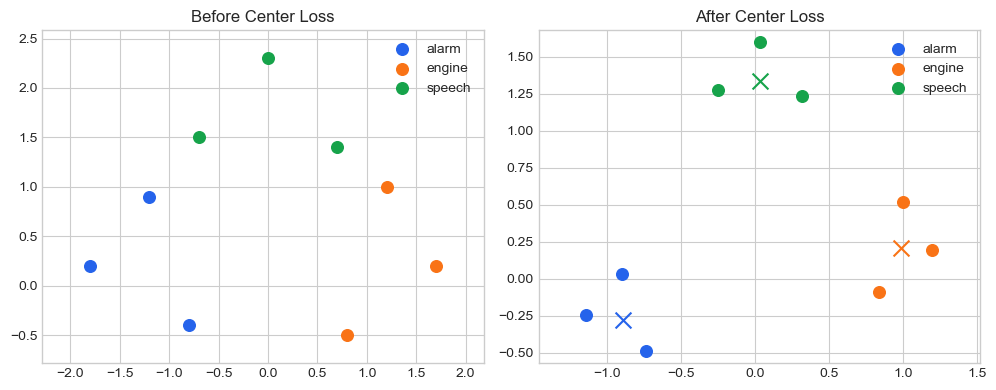

Center Loss: 1.6983 -> 0.0418


In [ ]:
# Optimize the toy embeddings and centers only to visualize compactness.
trainable_embeddings = nn.Parameter(embeddings.clone())
center_demo = CenterLoss(num_classes=3, embedding_dim=2)
optimizer = torch.optim.SGD([trainable_embeddings, *center_demo.parameters()], lr=0.18)

trajectory = []
for step in range(45):
    optimizer.zero_grad()
    loss = center_demo(trainable_embeddings, labels)
    loss.backward()
    optimizer.step()
    trajectory.append(loss.item())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for c in range(3):
    before = embeddings[labels == c]
    after = trainable_embeddings.detach()[labels == c]
    axes[0].scatter(before[:, 0], before[:, 1], s=70, color=colors[c], label=names[c])
    axes[1].scatter(after[:, 0], after[:, 1], s=70, color=colors[c], label=names[c])
    axes[1].scatter(*center_demo.centers.detach()[c], marker='x', s=130, color=colors[c])
axes[0].set_title('Before Center Loss')
axes[1].set_title('After Center Loss')
for ax in axes:
    ax.axis('equal')
    ax.legend()
plt.tight_layout()
plt.show()

print(f'Center Loss: {trajectory[0]:.4f} -> {trajectory[-1]:.4f}')

## 7. Angular losses: normalize first, then make angle matter

If both embeddings and class weights are L2-normalized, their dot product becomes cosine similarity:

$$\cos(\theta_k)=\frac{x^T w_k}{\lVert x\rVert\lVert w_k\rVert}$$

Normalization removes vector length as a shortcut. A scale $s$ then restores a useful logit range. Angular losses make the decision depend on how closely an embedding points toward its correct class direction.

### Angular Softmax / SphereFace: a multiplicative angular margin

Angular Softmax replaces the correct-class cosine with a stricter angular function:

$$z_y=s\cos(m\theta_y), \qquad z_{j\ne y}=s\cos(\theta_j)$$

The integer $m>1$ makes the acceptable angular region narrower. A production SphereFace implementation uses a piecewise monotonic correction because $\cos(m\theta)$ is not monotonic over the full angle range. The next cell is a controlled teaching demonstration in a safe angular region.

In [ ]:
def unit_vector_from_degrees(degrees):
    radians = torch.deg2rad(torch.tensor(degrees, dtype=torch.float32))
    return torch.stack([torch.cos(radians), torch.sin(radians)], dim=-1)

# Three examples are close to their correct class directions.
sphere_embeddings = unit_vector_from_degrees([10.0, 100.0, 240.0])
sphere_weights = unit_vector_from_degrees([0.0, 120.0, 240.0])
sphere_labels = torch.tensor([0, 1, 2])

cosine = F.normalize(sphere_embeddings, dim=1) @ F.normalize(sphere_weights, dim=1).T
theta = torch.acos(cosine.clamp(-1 + 1e-6, 1 - 1e-6))

scale = 16.0
m = 2
one_hot = F.one_hot(sphere_labels, num_classes=3).bool()
base_logits = scale * cosine
sphere_logits = scale * torch.where(one_hot, torch.cos(m * theta), cosine)

base_loss = F.cross_entropy(base_logits, sphere_labels)
sphere_loss = F.cross_entropy(sphere_logits, sphere_labels)

print(f'Normalized softmax loss: {base_loss.item():.4f}')
print(f'Angular Softmax demo, m={m}: {sphere_loss.item():.4f}')
print('Correct-class angles:', torch.rad2deg(theta[torch.arange(3), sphere_labels]).round().tolist())

Normalized softmax loss: 0.0000
Angular Softmax demo, m=2: 0.0000
Correct-class angles: [10.0, 20.0, 0.0]


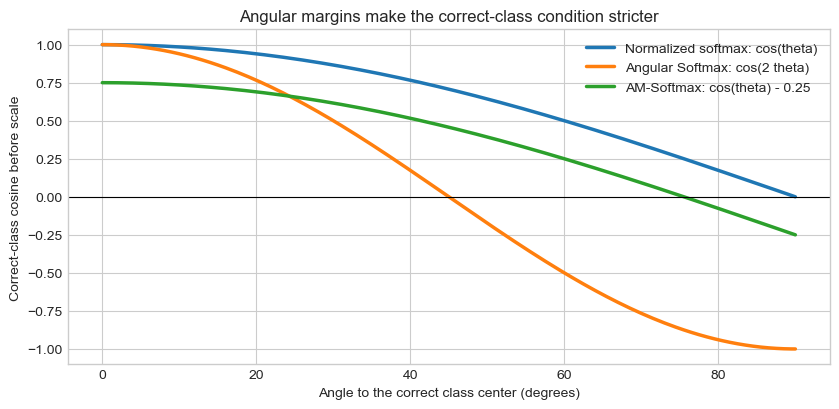

In [ ]:
angle_degrees = torch.linspace(0, 90, 181)
angle_radians = torch.deg2rad(angle_degrees)

standard_cosine = torch.cos(angle_radians)
sphereface_m2 = torch.cos(2 * angle_radians)
am_softmax_m025 = standard_cosine - 0.25

plt.figure(figsize=(8.5, 4.2))
plt.plot(angle_degrees, standard_cosine, label='Normalized softmax: cos(theta)', linewidth=2.5)
plt.plot(angle_degrees, sphereface_m2, label='Angular Softmax: cos(2 theta)', linewidth=2.5)
plt.plot(angle_degrees, am_softmax_m025, label='AM-Softmax: cos(theta) - 0.25', linewidth=2.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Angle to the correct class center (degrees)')
plt.ylabel('Correct-class cosine before scale')
plt.title('Angular margins make the correct-class condition stricter')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Additive Margin Softmax / CosFace

AM-Softmax subtracts a fixed cosine margin $m$ from the correct class before cross-entropy:

$$z_y=s(\cos\theta_y-m), \qquad z_{j\ne y}=s\cos\theta_j$$

Compared with multiplicative Angular Softmax, the margin is easier to interpret and tune: the correct class must beat competing cosine similarities by an extra fixed amount.

In [ ]:
class AMSoftmaxLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes, scale=16.0, margin=0.25):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(num_classes, embedding_dim))
        self.scale = scale
        self.margin = margin

    def forward(self, x, labels):
        x_unit = F.normalize(x, dim=1)
        w_unit = F.normalize(self.weight, dim=1)
        cosine = x_unit @ w_unit.T
        one_hot = F.one_hot(labels, num_classes=w_unit.shape[0]).to(cosine.dtype)
        margin_logits = self.scale * (cosine - one_hot * self.margin)
        return F.cross_entropy(margin_logits, labels), cosine, margin_logits

am_loss = AMSoftmaxLoss(embedding_dim=2, num_classes=3, scale=16.0, margin=0.25)
loss_with_margin, cosine, margin_logits = am_loss(embeddings, labels)

# Reuse the same weights with zero margin for a fair comparison.
original_margin = am_loss.margin
am_loss.margin = 0.0
loss_without_margin, _, _ = am_loss(embeddings, labels)
am_loss.margin = original_margin

print(f'Normalized softmax loss, m=0.00: {loss_without_margin.item():.4f}')
print(f'AM-Softmax loss,        m=0.25: {loss_with_margin.item():.4f}')

Normalized softmax loss, m=0.00: 1.0150
AM-Softmax loss,        m=0.25: 3.8865


In [ ]:
# The same model state, evaluated under stricter margins.
margins = [0.0, 0.1, 0.2, 0.3, 0.4]
losses = []
for margin in margins:
    am_loss.margin = margin
    current_loss, _, _ = am_loss(embeddings, labels)
    losses.append(current_loss.item())

for margin, value in zip(margins, losses):
    print(f'margin={margin:.1f} -> loss={value:.4f}')
am_loss.margin = 0.25

margin=0.0 -> loss=1.0150
margin=0.1 -> loss=1.9718
margin=0.2 -> loss=3.2085
margin=0.3 -> loss=4.5846
margin=0.4 -> loss=6.0200


**Terminology note.** This notebook implements an additive **cosine** margin (AM-Softmax / CosFace). ArcFace uses an additive **angular** margin inside $\cos(\theta+m)$ and belongs naturally in an advanced Part 2 discussion.

## 9. Contrastive losses: compare samples, not only classes

The losses above compare an example with a target value or class center. Contrastive objectives compare examples with each other.

A classic pairwise contrastive loss uses a same/different label $y$:

$$L=y\,d^2 + (1-y)\max(0, \alpha-d)^2$$

- a same-class pair pays for being far apart;
- a different-class pair pays only when it is closer than margin $\alpha$.

In [ ]:
pair_a = torch.tensor([[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]])
pair_b = torch.tensor([[0.2, 0.1], [1.4, 1.2], [2.0, 2.0], [0.4, 0.3]])
same_pair = torch.tensor([1.0, 1.0, 0.0, 0.0])
pair_names = ['same / close', 'same / far', 'different / far', 'different / close']
pair_margin = 1.0

distance = F.pairwise_distance(pair_a, pair_b)
pair_loss = same_pair * distance.square() + (1 - same_pair) * F.relu(pair_margin - distance).square()

for name, d, value in zip(pair_names, distance, pair_loss):
    print(f'{name:18s} distance={d.item():.3f}  loss={value.item():.3f}')

same / close       distance=0.224  loss=0.050
same / far         distance=1.844  loss=3.400
different / far    distance=2.828  loss=0.000
different / close  distance=0.500  loss=0.250


### Triplet Loss: learn a relative ordering

A triplet contains an anchor $a$, a positive $p$ from the same class, and a negative $n$ from another class:

$$L=\max(0, d(a,p)-d(a,n)+\alpha)$$

The loss is active only when the negative is not sufficiently farther away than the positive.

In [ ]:
anchor = torch.tensor([[0.0, 0.0]])
positive = torch.tensor([[0.4, 0.2]])
easy_negative = torch.tensor([[2.0, 2.0]])
hard_negative = torch.tensor([[0.6, 0.3]])
margin = 0.5

easy_loss = F.triplet_margin_loss(anchor, positive, easy_negative, margin=margin)
hard_loss = F.triplet_margin_loss(anchor, positive, hard_negative, margin=margin)

print(f'Easy triplet loss: {easy_loss.item():.4f}')
print(f'Hard triplet loss: {hard_loss.item():.4f}')

Easy triplet loss: 0.0000
Hard triplet loss: 0.2764


In [ ]:
def batch_hard_triplet_loss(x, labels, margin=0.4):
    distances = torch.cdist(x, x)
    same_class = labels[:, None].eq(labels[None, :])
    different_class = ~same_class
    same_class.fill_diagonal_(False)

    hardest_positive = distances.masked_fill(~same_class, float('-inf')).max(dim=1).values
    hardest_negative = distances.masked_fill(~different_class, float('inf')).min(dim=1).values
    active_loss = F.relu(hardest_positive - hardest_negative + margin)
    return active_loss.mean(), hardest_positive, hardest_negative, active_loss

mined_loss, hard_pos, hard_neg, active = batch_hard_triplet_loss(embeddings, labels)
print(f'Batch-hard triplet loss: {mined_loss.item():.4f}')
print('Active anchors:', int((active > 0).sum()), 'of', len(active))

Batch-hard triplet loss: 0.5537
Active anchors: 6 of 9


**Why mining matters.** If nearly every triplet is already easy, the loss is zero and training stalls. Hard or semi-hard mining chooses informative comparisons, but excessively noisy hard negatives can destabilize training.

## 10. Mini-lab: combine CE and Center Loss

The following toy model learns a 2D embedding and a 3-class classifier. The objective combines prediction accuracy with embedding compactness.

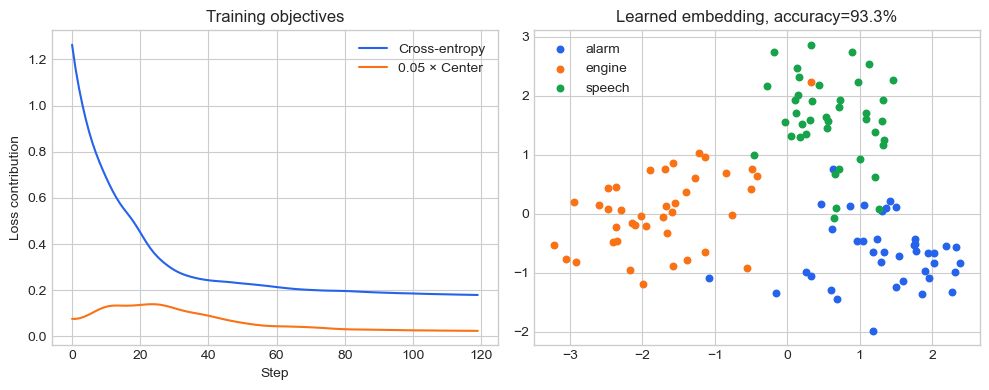

In [ ]:
# Synthetic 2D inputs from three overlapping classes.
n_per_class = 40
raw_x = torch.cat([
    torch.randn(n_per_class, 2) * 0.65 + torch.tensor([-1.3, 0.0]),
    torch.randn(n_per_class, 2) * 0.65 + torch.tensor([1.3, 0.0]),
    torch.randn(n_per_class, 2) * 0.65 + torch.tensor([0.0, 1.7]),
])
raw_y = torch.arange(3).repeat_interleave(n_per_class)

class TinyEmbedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(2, 12), nn.ReLU(), nn.Linear(12, 2))
        self.classifier = nn.Linear(2, 3)

    def forward(self, x):
        embedding = self.encoder(x)
        return embedding, self.classifier(embedding)

net = TinyEmbedNet()
center_term = CenterLoss(num_classes=3, embedding_dim=2)
optimizer = torch.optim.Adam([*net.parameters(), *center_term.parameters()], lr=0.025)

history = []
for step in range(120):
    optimizer.zero_grad()
    z, class_logits = net(raw_x)
    ce = F.cross_entropy(class_logits, raw_y)
    compactness = center_term(z, raw_y)
    total = ce + 0.05 * compactness
    total.backward()
    optimizer.step()
    history.append((ce.item(), compactness.item(), total.item()))

with torch.no_grad():
    final_z, final_logits = net(raw_x)
    accuracy = (final_logits.argmax(dim=1) == raw_y).float().mean().item()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot([v[0] for v in history], label='Cross-entropy', color='#2563eb')
axes[0].plot([0.05 * v[1] for v in history], label='0.05 × Center', color='#f97316')
axes[0].set(title='Training objectives', xlabel='Step', ylabel='Loss contribution')
axes[0].legend()
for c in range(3):
    pts = final_z[raw_y == c]
    axes[1].scatter(pts[:, 0], pts[:, 1], s=22, color=colors[c], label=names[c])
axes[1].set_title(f'Learned embedding, accuracy={accuracy:.1%}')
axes[1].legend()
plt.tight_layout()
plt.show()

## 11. Loss-selection map

| Task structure | Primary objective | Useful addition | Critical input contract |
|---|---|---|---|
| Continuous target | MSE, MAE, or Huber | Match the residual geometry to outliers | Prediction and target have the same shape |
| One of $C$ classes | Cross-entropy | Label smoothing or class weights | Raw logits `[N, C]`; integer targets `[N]` |
| Independent yes/no labels | BCE with logits | `pos_weight` for imbalance | Raw logits and float targets have the same shape |
| Compact class embeddings | CE + Center Loss | Tune $\lambda$ | Optimize both model and centers |
| Angular class separation | Angular Softmax or AM-Softmax | Multiplicative or additive margin | Normalize embeddings and class weights |
| Pair similarity | Contrastive Loss | Tune distance margin | Construct meaningful positive and negative pairs |
| Relative similarity | Triplet Loss | Hard/semi-hard mining | Construct informative anchor-positive-negative sets |

## 12. Practice: try before revealing the answers

**A. API debugging**

The next cell contains two common mistakes. Edit it so both losses receive the correct inputs.

In [ ]:
# Exercise cell: uncomment and repair.
# multiclass_probabilities = torch.tensor([[0.7, 0.2, 0.1]])
# target = torch.tensor([0])
# loss_a = F.cross_entropy(multiclass_probabilities, target)  # What should be passed instead?

# binary_probabilities = torch.tensor([0.9, 0.1])
# binary_target = torch.tensor([1.0, 0.0])
# loss_b = F.binary_cross_entropy_with_logits(binary_probabilities, binary_target)  # What should be passed instead?

**Solution.** Keep the final linear outputs as logits. Pass multiclass logits directly to cross-entropy, and binary logits directly to BCE with logits. Apply softmax or sigmoid only when probabilities are needed for interpretation.

In [ ]:
multiclass_logits = torch.tensor([[1.8, 0.4, -0.2]])
multiclass_target = torch.tensor([0])
loss_a = F.cross_entropy(multiclass_logits, multiclass_target)

binary_logits = torch.tensor([2.2, -2.2])
binary_target = torch.tensor([1.0, 0.0])
loss_b = F.binary_cross_entropy_with_logits(binary_logits, binary_target)

print(f'Correct multiclass CE: {loss_a.item():.4f}')
print(f'Correct binary BCE:    {loss_b.item():.4f}')

Correct multiclass CE: 0.3235
Correct binary BCE:    0.1051


## Takeaways

1. A loss is a design choice about which mistakes receive gradient.
2. MAE, MSE, and Huber encode different beliefs about large residuals.
3. In PyTorch, use logits for `CrossEntropyLoss` and `BCEWithLogitsLoss`.
4. Fixed-class accuracy and transferable embedding geometry are related but different objectives.
5. Center Loss adds compactness; Angular Softmax and AM-Softmax add stricter angular separation.
6. Contrastive and Triplet Loss depend on informative pair or triplet construction.
7. Validate shapes, reductions, target encodings, sampling, and gradient flow before tuning hyperparameters.

## References

- PyTorch: [`MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)
- PyTorch: [`L1Loss`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html)
- PyTorch: [`HuberLoss`](https://pytorch.org/docs/stable/generated/torch.nn.HuberLoss.html)
- PyTorch: [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
- PyTorch: [`BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)
- PyTorch: [`TripletMarginLoss`](https://pytorch.org/docs/stable/generated/torch.nn.TripletMarginLoss.html)
- Wen et al., *A Discriminative Feature Learning Approach for Deep Face Recognition*, ECCV 2016
- Liu et al., *SphereFace: Deep Hypersphere Embedding for Face Recognition*, CVPR 2017
- Wang et al., *Additive Margin Softmax for Face Verification*, 2018
- Hadsell et al., *Dimensionality Reduction by Learning an Invariant Mapping*, CVPR 2006